<a href="https://colab.research.google.com/github/Anothaatype/PCVK-Semester-5/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Importing Drive From Google Colab
from google.colab import drive

#Accessing Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
import os
import glob
from google.colab.patches import cv2_imshow
from skimage import io

In [15]:
# Set Image path
image_path = '/content/drive/MyDrive/PCVK_MM/Images-Polinema/lena.jpg'

print(f"Image path set to: {image_path}")
print("Checking if file exists...")

import os
if os.path.exists(image_path):
    print("✓ Image file found!")
else:
    print("✗ Image file not found. Please check the path.")
    print("Available files in the directory:")
    directory = os.path.dirname(image_path)
    if os.path.exists(directory):
        files = os.listdir(directory)
        for file in files:
            print(f"  - {file}")
    else:
        print(f"Directory {directory} does not exist.")

Image path set to: /content/drive/MyDrive/PCVK_MM/Images-Polinema/lena.jpg
Checking if file exists...
✓ Image file found!


### 3.Histogram RGB Distribution

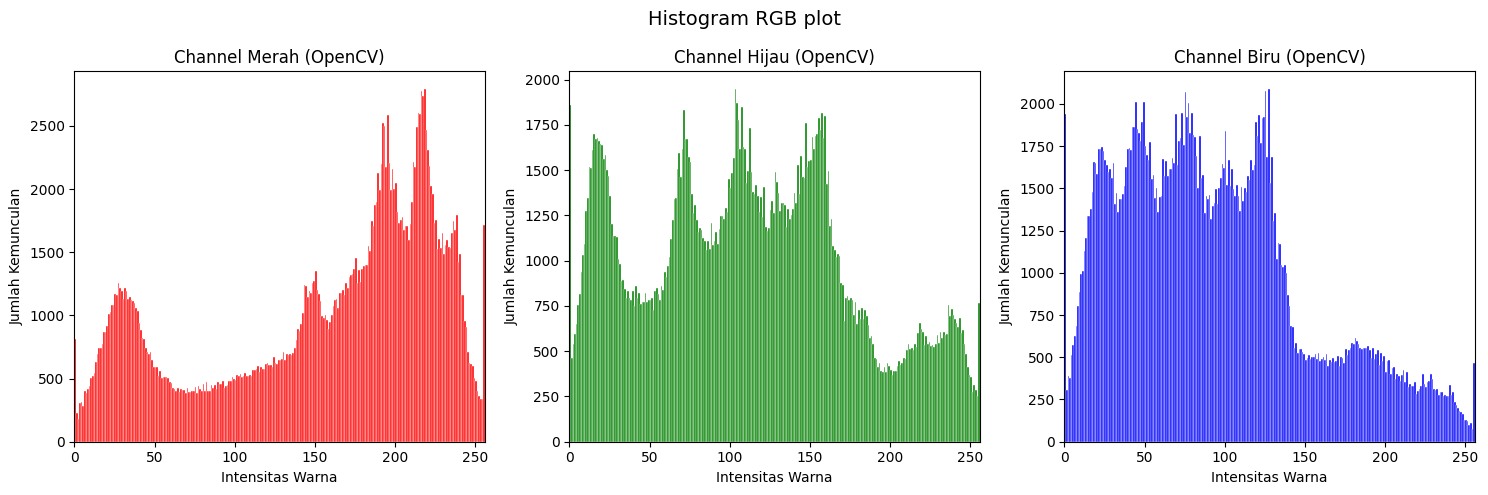

In [29]:
# Warna channel
colors = ('r', 'g', 'b')
titles = ('Merah', 'Hijau', 'Biru')

# Plot histogram RGB secara terpisah (full bar style with edgecolor)
plt.figure(figsize=(15,5))
for i, col in enumerate(colors):
    plt.subplot(1, 3, i+1)

    # Ambil channel i (0=R, 1=G, 2=B)
    channel_data = img_rgb[:,:,i].ravel()

    # Gunakan plt.hist langsung pada pixel values
    plt.hist(channel_data, bins=256, range=(0,256),
             color=col, edgecolor='white', linewidth = 0.3)

    plt.xlim([0,256])
    plt.title(f'Channel {titles[i]} (OpenCV)')
    plt.xlabel('Intensitas Warna')
    plt.ylabel('Jumlah Kemunculan')

plt.suptitle("Histogram RGB plot", fontsize=14)
plt.tight_layout()
plt.show()

### 4. make the same image histogram but use the library that is owned by NumPy, namely " histogram ". Compare the results. Does the output appear the same?

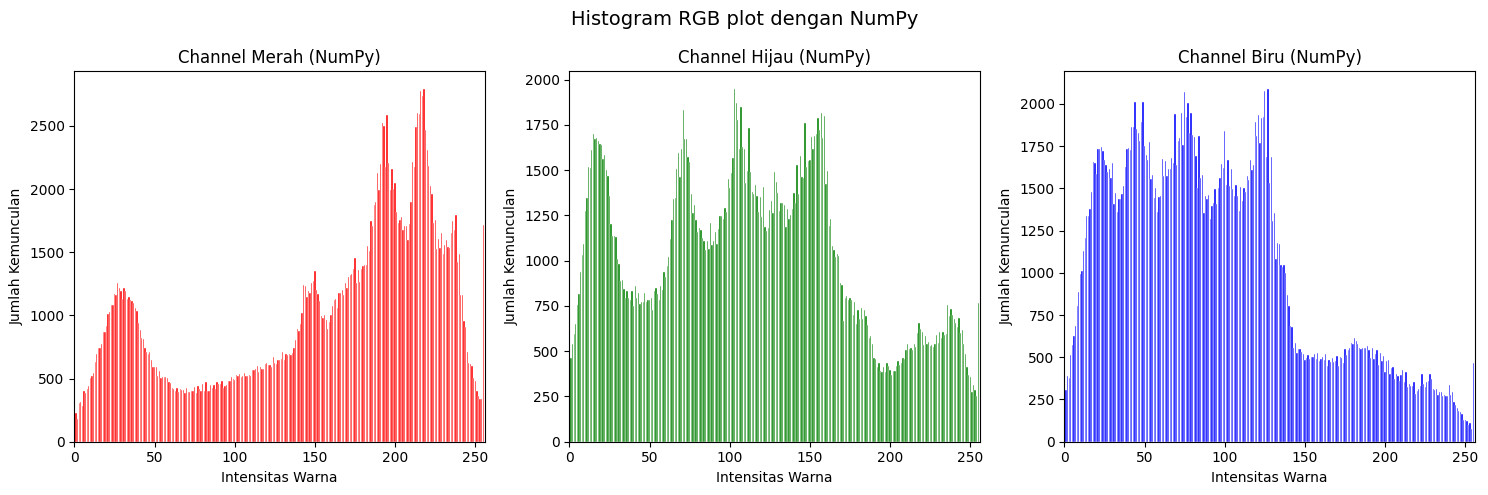

In [26]:
# Input image
img = cv.imread(image_path)
if img is None:
    raise FileNotFoundError("Image could not be read. Check the path again.")

# Convert to RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Warna channel
colors = ('r', 'g', 'b')
titles = ('Merah', 'Hijau', 'Biru')

# Plot histogram dengan NumPy
plt.figure(figsize=(15,5))
for i, col in enumerate(colors):
    plt.subplot(1, 3, i+1)

    # Ambil pixel values untuk tiap channel
    channel_data = img_rgb[:,:,i].ravel()

    # Hitung histogram pakai NumPy
    hist, bins = np.histogram(channel_data, bins=256, range=(0,256))

    # Plot sebagai bar
    plt.bar(bins[:-1], hist, color=col, edgecolor='white', linewidth = 0.3)

    plt.xlim([0,256])
    plt.title(f'Channel {titles[i]} (NumPy)')
    plt.xlabel('Intensitas Warna')
    plt.ylabel('Jumlah Kemunculan')

plt.suptitle("Histogram RGB plot dengan NumPy", fontsize=14)
plt.tight_layout()
plt.show()


#### Explanations:
The expected output remain the same because both OpenCV's cv2.calcHist() and NumPy's numpy.histogram() functions implement the same fundamental histogram calculation algorithm - they both count pixel occurrences within defined intensity bins across the 0-255 range. The minor visual differences, if any, are likely due to slight variations in plotting parameters or binning strategies, but the underlying data analysis remains consistent. This demonstrates that while different libraries may have different syntax and implementation details, they produce equivalent statistical representations of the image data, confirming the reliability of both approaches for image analysis tasks

### 5.Make an image histogram such as the output equalization histogram and also the image display before and after the following equalization histogram process based on the flowchart below : (Use image lena_lc .jpg)

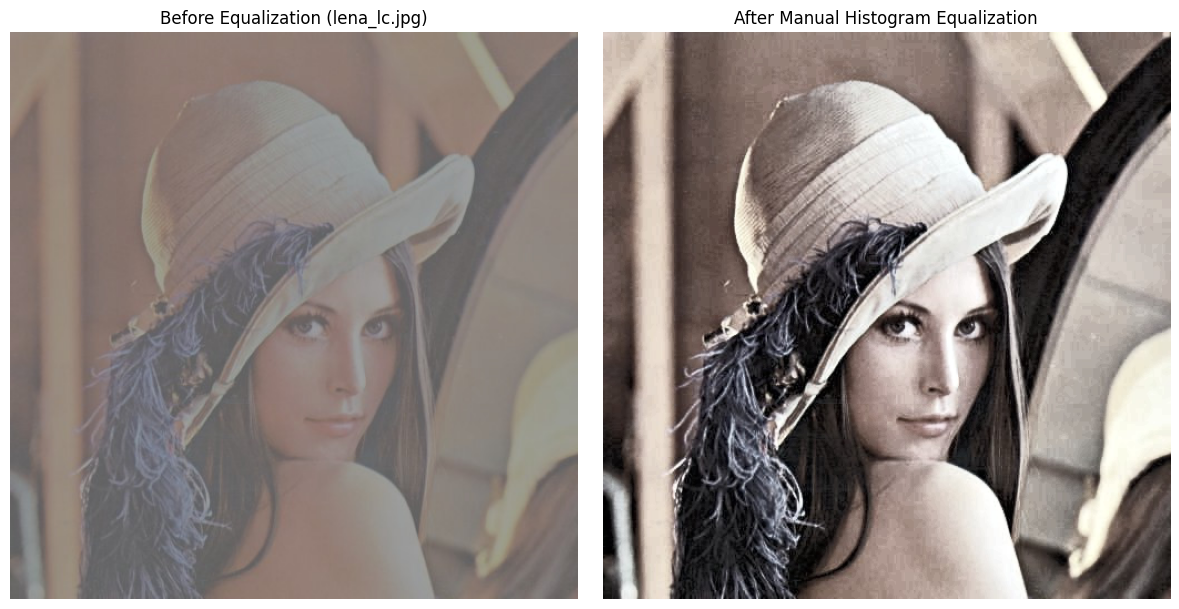

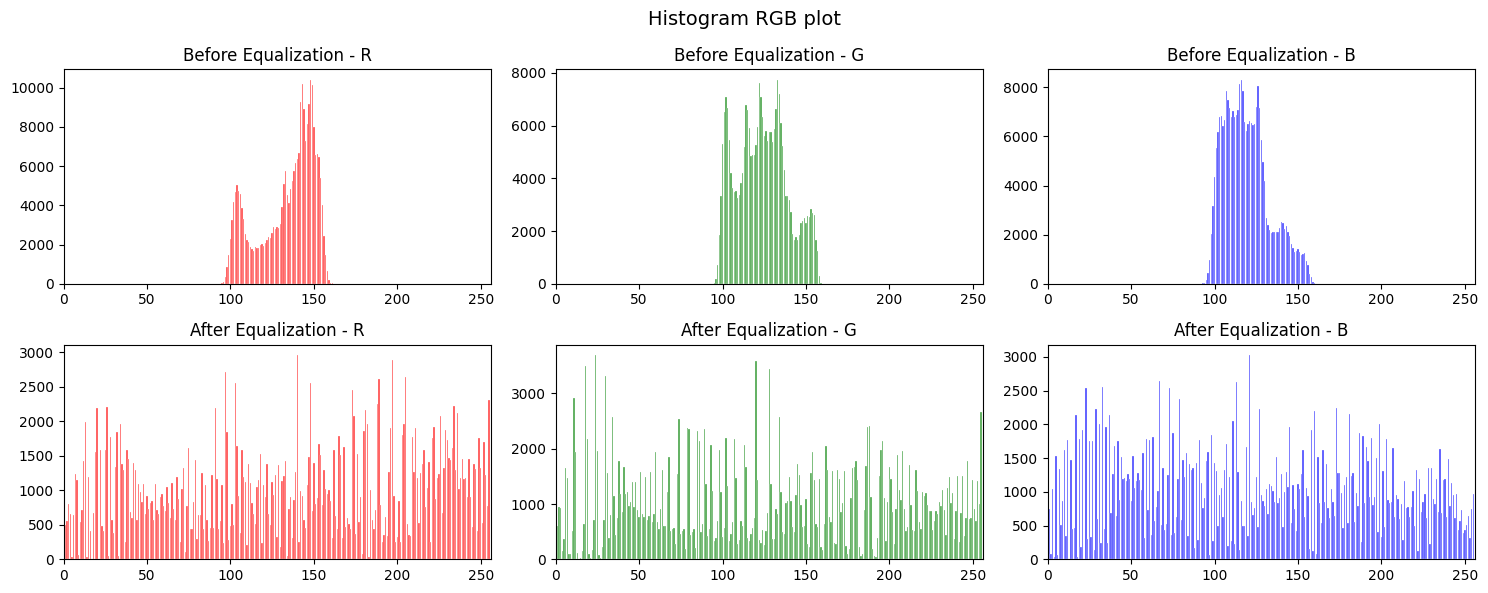

In [51]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the input image (lena_lc.jpg)
img_input = cv.imread("/content/drive/MyDrive/PCVK_MM/Images-Polinema/lena_lc.jpg")
if img_input is None:
    raise FileNotFoundError("Check lena_lc.jpg path.")

# Convert BGR to RGB for display
img_input_rgb = cv.cvtColor(img_input, cv.COLOR_BGR2RGB)

# Step 2: Manual Histogram Equalization Implementation (following the flowchart)

# Convert to YCrCb for processing luminance channel only
ycrcb = cv.cvtColor(img_input, cv.COLOR_BGR2YCrCb)
y_channel, cr_channel, cb_channel = cv.split(ycrcb)

# Manual histogram equalization process
def manual_histogram_equalization(image):
    # Get image dimensions
    height, width = image.shape
    total_pixels = height * width

    # Step 1: Calculate frequency of each intensity value (0-255)
    histogram = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            pixel_value = image[i, j]
            histogram[pixel_value] += 1

    # Step 2: Calculate cumulative frequency
    cumulative_freq = np.zeros(256, dtype=int)
    cumulative_freq[0] = histogram[0]
    for i in range(1, 256):
        cumulative_freq[i] = cumulative_freq[i-1] + histogram[i]

    # Step 3: Normalize cumulative frequency and create transformation function
    transformation = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        transformation[i] = round((cumulative_freq[i] * 255) / total_pixels)

    # Step 4: Apply transformation to create equalized image
    equalized_image = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            equalized_image[i, j] = transformation[image[i, j]]

    return equalized_image

# Apply manual histogram equalization to Y channel
y_equalized = manual_histogram_equalization(y_channel)

# Merge channels back and convert to RGB
ycrcb_equalized = cv.merge([y_equalized, cr_channel, cb_channel])
img_equalized_rgb = cv.cvtColor(ycrcb_equalized, cv.COLOR_YCrCb2RGB)

# Display images before and after equalization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_input_rgb)
plt.title("Before Equalization (lena_lc.jpg)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_equalized_rgb)
plt.title("After Manual Histogram Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()

# Function to plot RGB histograms
def plot_rgb_hist(axs, image, titles):
    colors = ('r','g','b')
    for i, col in enumerate(colors):
        hist = cv.calcHist([image], [i], None, [256], [0,256])
        axs[i].bar(
            range(256), hist.ravel(),
            color=col,
            linewidth=0.3,
            edgecolor="white",
            alpha=0.7
        )
        axs[i].set_xlim([0,256])
        axs[i].set_title(f'{titles} - {col.upper()}')

# Show histograms (before vs after equalization)
fig, axs = plt.subplots(2, 3, figsize=(15,6))
plot_rgb_hist(axs[0], img_input_rgb, "Before Equalization")
plot_rgb_hist(axs[1], img_equalized_rgb, "After Equalization")
plt.suptitle("Histogram RGB plot", fontsize=14)
plt.tight_layout()
plt.show()

### 6.After working on question no. 5, make the same image histogram but use the library owned by CV2, namely " equalizeHist ". Compare the results. Does the output appear the same?

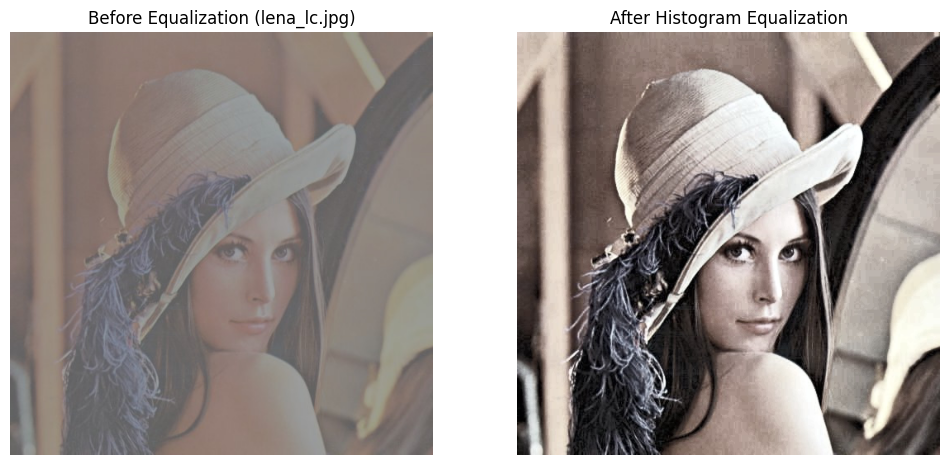

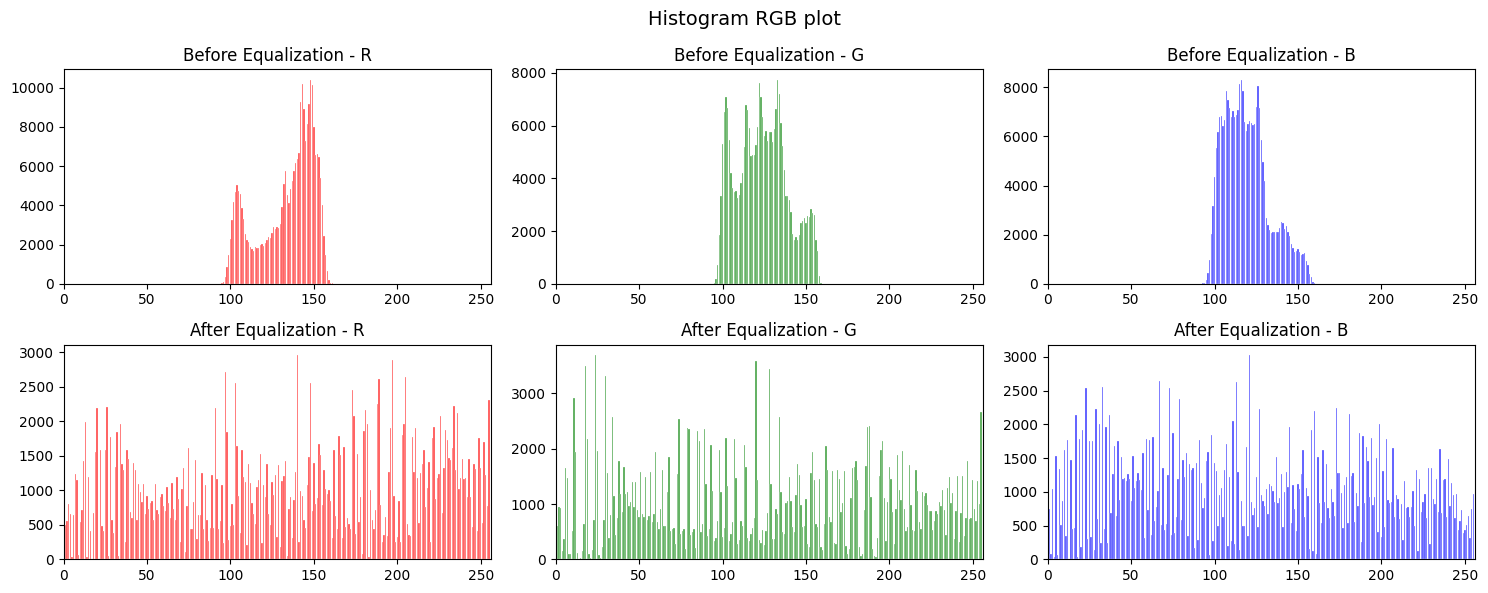

In [52]:
import cv2 as cv
import matplotlib.pyplot as plt

# Step 1: Read image
img_low = cv.imread("/content/drive/MyDrive/PCVK_MM/Images-Polinema/lena_lc.jpg") # Low contrast
if img_low is None:
    raise FileNotFoundError("Check lena_lc.jpg path.")

# Convert BGR -> RGB for display
img_low_rgb = cv.cvtColor(img_low, cv.COLOR_BGR2RGB)

# Step 2: Equalize low contrast image (Y channel only)
ycrcb_low = cv.cvtColor(img_low, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb_low)
y_eq = cv.equalizeHist(y)
ycrcb_eq = cv.merge([y_eq, cr, cb])
img_eq_rgb = cv.cvtColor(ycrcb_eq, cv.COLOR_YCrCb2RGB)

# Step 3: Function to plot RGB histograms
def plot_rgb_hist(axs, image, titles):
    colors = ('r','g','b')
    for i, col in enumerate(colors):
        hist = cv.calcHist([image], [i], None, [256], [0,256])
        axs[i].bar(
            range(256), hist.ravel(),
            color=col,
            linewidth=0.3,
            edgecolor="white",
            alpha=0.7
        )
        axs[i].set_xlim([0,256])
        axs[i].set_title(f'{titles} - {col.upper()}')

# Step 4: Show images (before vs after equalization)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_low_rgb)
plt.title("Before Equalization (lena_lc.jpg)")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(img_eq_rgb)
plt.title("After Histogram Equalization")
plt.axis("off")
plt.show()

# Step 5: Show histograms
fig, axs = plt.subplots(2, 3, figsize=(15,6))
plot_rgb_hist(axs[0], img_low_rgb, "Before Equalization")
plot_rgb_hist(axs[1], img_eq_rgb, "After Equalization")
plt.suptitle("Histogram RGB plot", fontsize=14)
plt.tight_layout()
plt.show()

#### Explanations :
The output does not appear the same. The original histogram has concentrated peaks, while the equalized histogram is more evenly distributed, with higher spread and sometimes sharp spikes at the extremes (0 and 255). This difference confirms that histogram equalization successfully improves the contrast of the image.

### 7. Do the mapping process of 16 million RGB colors into just 8 colors, namely black, green, yellow, blue, cyan, magenta, white as shown in the following output based on the flowchart below! (Use the image testlena .jpg)

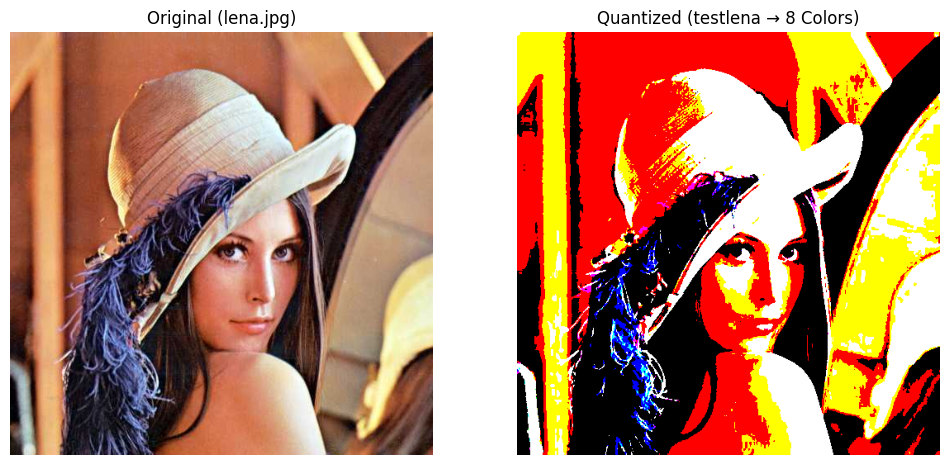

In [48]:
# Step 1: Read both images
img_lena = cv.imread("/content/drive/MyDrive/PCVK_MM/Images-Polinema/lena.jpg")        # Original lena.jpg
img_testlena = cv.imread("/content/drive/MyDrive/PCVK_MM/Images-Polinema/testlena.jpg") # Testlena for quantization

# Convert to RGB
img_lena_rgb = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)
img_testlena_rgb = cv.cvtColor(img_testlena, cv.COLOR_BGR2RGB)

# Step 2: Quantize testlena → 8 colors
quantized = np.where(img_testlena_rgb < 128, 0, 255).astype(np.uint8)

# Step 3: Display lena.jpg vs quantized testlena
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_lena_rgb)
plt.title("Original (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(quantized)
plt.title("Quantized (testlena → 8 Colors)")
plt.axis("off")

plt.show()

### 8. Do the Floyd and Steinberg dithering process like the following output (initial image display, and after dithering display) based on the flowchart below! (Use wiki.jpg image)

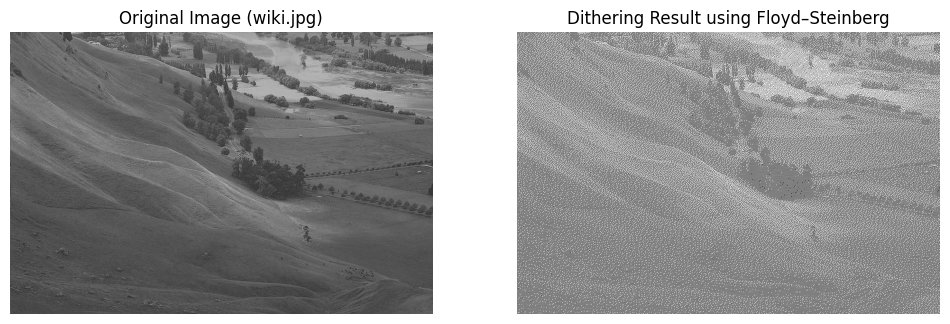

In [49]:
# Step 1: Read the grayscale image
img = cv.imread("/content/drive/MyDrive/PCVK_MM/Images-Polinema/wiki.jpg", cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Check the path for wiki.jpg")

# Copy image for dithering
dithered = img.copy().astype(np.float32)

# Step 2: Floyd-Steinberg dithering
rows, cols = dithered.shape
for y in range(rows):
    for x in range(cols):
        old_pixel = dithered[y, x]
        new_pixel = 0 if old_pixel < 128 else 255
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Distribute error to neighbors
        if x+1 < cols:
            dithered[y, x+1] += error * 7/16
        if y+1 < rows and x > 0:
            dithered[y+1, x-1] += error * 3/16
        if y+1 < rows:
            dithered[y+1, x] += error * 5/16
        if y+1 < rows and x+1 < cols:
            dithered[y+1, x+1] += error * 1/16

# Convert back to uint8
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Step 3: Display results
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original Image (wiki.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dithered, cmap="gray")
plt.title("Dithering Result using Floyd–Steinberg")
plt.axis("off")

plt.show()